<a href="https://colab.research.google.com/github/The-Gamer2/heart-disease-data-preprocessing/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AnalystLab Africa Data Science Internship**
# **Week 2: Feature Engineering & Data Preprocessing for Machine Learning**

# **Heart Disease Prediction**

## 1. Setup, Data Loading and data inspection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Set display options for better viewing of DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ Data Science Intern/week 2/heart.csv')

# Display the first 5 rows of the DataFrame
print("First 10 rows:")
display(df.head(10))


First 10 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
# Display the last 5 rows of the DataFrame
print("\nLast 10 rows:")
display(df.tail(10))


Last 10 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
908,63,M,ASY,140,187,0,LVH,144,Y,4.0,Up,1
909,63,F,ASY,124,197,0,Normal,136,Y,0.0,Flat,1
910,41,M,ATA,120,157,0,Normal,182,N,0.0,Up,0
911,59,M,ASY,164,176,1,LVH,90,N,1.0,Flat,1
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


The first and last 10 records were displayed to understand the dataset structure, column names, and the type of values recorded for each patient.

In [ ]:
# Display the shape of the DataFrame (rows, columns)
print(f"\nShape: {df.shape[0]} rows and {df.shape[1]} columns")


Shape: 918 rows and 12 columns


In [ ]:
# Display column names
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


There are 11 predictor variables and one target variable, **HeartDisease**

In [ ]:
# Columns with only one unique value
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns:", constant_cols)
df[constant_cols].nunique()

Constant columns: []


,0


In [ ]:
# Display concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


The dataset contains both numerical and categorical variables. Numerical variables include Age, RestingBP, Cholesterol, FastingBS, MaxHR, Oldpeak, and HeartDisease. Categorical variables include Sex, ChestPainType, RestingECG, ExerciseAngina, and ST_Slope.

Categorical variables will need to be encoded before training most machine-learning models.

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

Missing values per column:
Series([], dtype: int64)
No missing values found in the dataset.


The missing-value assessment found no null values in the dataset. Therefore, no imputation method is required for explicitly missing values.

In [ ]:
# Check for duplicate records
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("\nFirst 5 duplicate rows (if any):")
    display(df[df.duplicated()].head())

Number of duplicate rows: 0


Duplicate records were checked to prevent repeated observations from influencing the machine-learning model. Here they are not duplicate row.

In [ ]:
# Display summary statistics for numerical columns
print("\nSummary Statistics for Numerical Columns:")
display(df.describe().T)


Summary Statistics for Numerical Columns:


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [ ]:
# Display summary statistics for categorical columns
print("\nSummary Statistics for Categorical Columns:")
display(df.describe(include='object').T)


Summary Statistics for Categorical Columns:


,count,unique,top,freq
Sex,918,2,M,725
ChestPainType,918,4,ASY,496
RestingECG,918,3,Normal,552
ExerciseAngina,918,2,N,547
ST_Slope,918,3,Flat,460


The categorical summary shows the number of unique categories and the most frequent category for each categorical feature

***class distribution of the target variable***

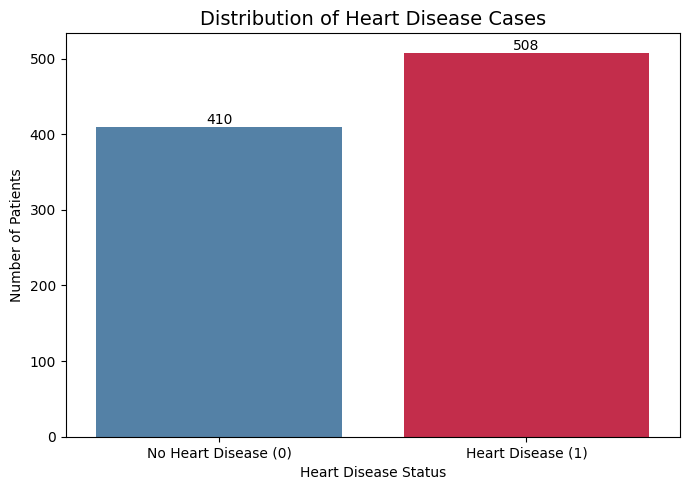

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="HeartDisease",
    hue="HeartDisease",
    palette={0: "steelblue", 1: "crimson"},
    legend=False
)

plt.title("Distribution of Heart Disease Cases", fontsize=14)
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

ax.set_xticks([0, 1])
ax.set_xticklabels(["No Heart Disease (0)", "Heart Disease (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

***distribution of patient age***

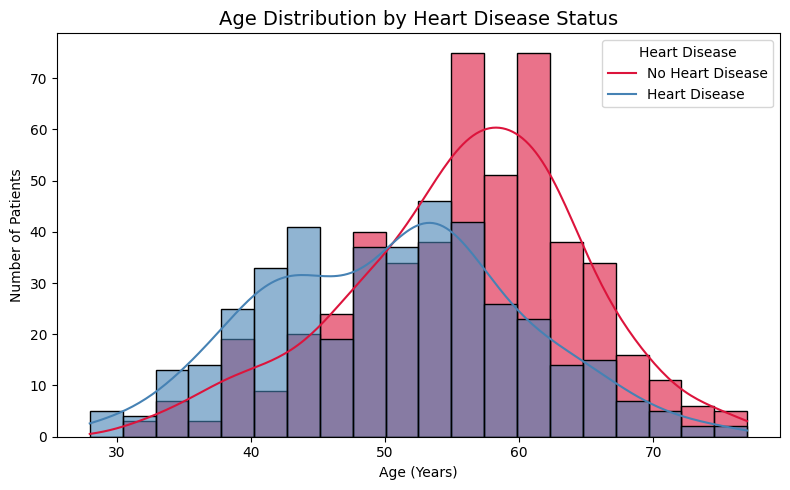

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="HeartDisease",
    bins=20,
    kde=True,
    palette={0: "steelblue", 1: "crimson"},
    alpha=0.6
)

plt.title("Age Distribution by Heart Disease Status", fontsize=14)
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease", labels=["No Heart Disease", "Heart Disease"]) # Corrected label order

plt.tight_layout()
plt.show()

The histogram displays the distribution of patient age and compares patients with and without heart disease.

***maximum heart rate vs age***

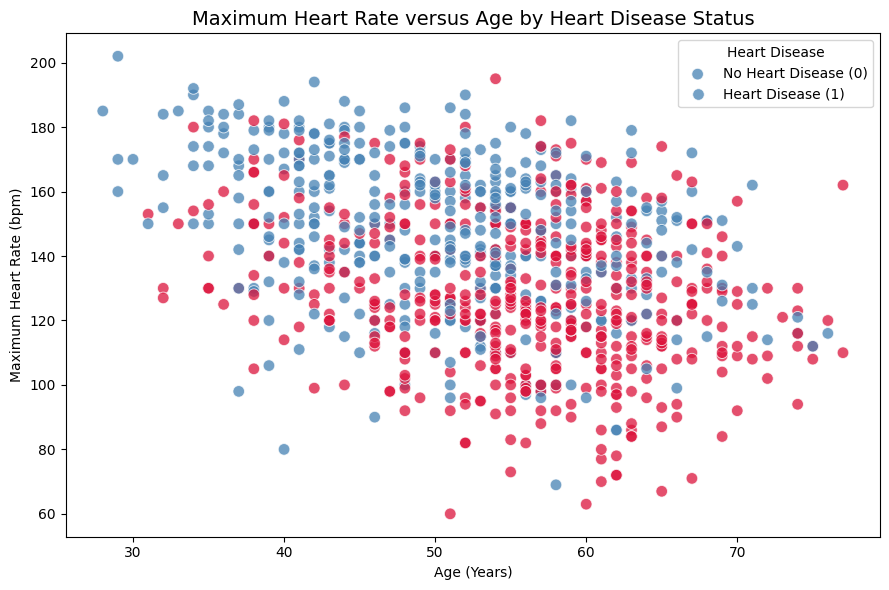

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="MaxHR",
    hue="HeartDisease",
    palette={0: "steelblue", 1: "crimson"},
    alpha=0.75,
    s=70
)

plt.title("Maximum Heart Rate versus Age by Heart Disease Status", fontsize=14)
plt.xlabel("Age (Years)")
plt.ylabel("Maximum Heart Rate (bpm)")
plt.legend(
    title="Heart Disease",
    labels=["No Heart Disease (0)", "Heart Disease (1)"]
)

plt.tight_layout()
plt.show()

The scatter plot shows the relationship between age and maximum heart rate. The color grouping makes it possible to observe whether patients with heart disease tend to appear in different regions of the plot compared with patients without heart disease.

## 2. Feature Engineering & Data Preprocessing

## Data Cleaning

As previously verified, our dataset is already quite clean. We will recap the cleaning steps.

### Handling Missing Values

We have confirmed that there are **no missing values** in the dataset, so no action is needed at this stage.

### Removing Duplicates

We have also checked and confirmed that there are **no duplicate records** in the dataset, meaning each observation is unique.

### Correcting Data Types

Upon reviewing `df.info()`, the current data types seem appropriate. Numerical columns (`Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`, `HeartDisease`) are `int64` or `float64`, and categorical columns (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`) are `object`.

`FastingBS` (0: low blood sugar, 1: high blood sugar) and `HeartDisease` (0: no, 1: yes) are binary variables represented as integers, which is acceptable for machine learning models. For now, no data type modifications are necessary.

## Feature Engineering

Feature engineering involves creating new features from existing ones or transforming them to improve model performance.

### Creating New Features

For this dataset, no obvious new features seem immediately necessary without additional domain expertise. Potential features could include interaction terms (e.g., Age * Cholesterol) or polynomial features, but we will stick to the existing features for now to maintain simplicity. If more information is provided, this step can be revisited.

### Removing Irrelevant Features

All current features (`Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBS`, `RestingECG`, `MaxHR`, `ExerciseAngina`, `Oldpeak`, `ST_Slope`, `HeartDisease`) appear to be potentially relevant for heart disease prediction. No features will be removed at this stage.

### Renaming Columns for Clarity

The current column names are already clear and descriptive (`Age`, `Sex`, `ChestPainType`, etc.). No name changes are necessary.

## Feature Encoding

Machine learning models cannot work directly with categorical variables. We need to convert them into numerical representations. We will use *Label Encoding* for binary variables and *One-Hot Encoding* for multi-class nominal categorical variables.

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Create a copy of the DataFrame for encoding to avoid modifying the original
df_encoded = df.copy()

# Apply Label Encoding for binary categorical columns
# Sex: M/F -> 1/0
# ExerciseAngina: Y/N -> 1/0

# We will encode Sex and ExerciseAngina
label_encoder = LabelEncoder()

df_encoded['Sex'] = label_encoder.fit_transform(df_encoded['Sex'])

df_encoded['ExerciseAngina'] = label_encoder.fit_transform(df_encoded['ExerciseAngina'])

print("DataFrame after Label Encoding:")
display(df_encoded[['Sex', 'ExerciseAngina']].head())

print("\nUnique values of 'Sex' after encoding:", df_encoded['Sex'].unique())
print("Unique values of 'ExerciseAngina' after encoding:", df_encoded['ExerciseAngina'].unique())

DataFrame after Label Encoding:


,Sex,ExerciseAngina
0,1,0
1,0,0
2,1,0
3,0,1
4,1,0



Unique values of 'Sex' after encoding: [1 0]
Unique values of 'ExerciseAngina' after encoding: [0 1]


**Label Encoding** was applied to binary categorical features like `Sex` and `ExerciseAngina`. This technique is suitable for binary variables because it assigns a unique integer (0 or 1) to each category, which is computationally efficient and avoids creating unnecessary new columns.

In [ ]:
# Apply One-Hot Encoding for multi-class nominal categorical columns
# 'ChestPainType', 'RestingECG', 'ST_Slope'

# Use pandas get_dummies for One-Hot Encoding as it is easy to use
df_encoded = pd.get_dummies(df_encoded, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)

print("\nDataFrame after One-Hot Encoding (preview of new columns):")
display(df_encoded.head())

print("\nNew columns after One-Hot Encoding:")
print([col for col in df_encoded.columns if 'ChestPainType' in col or 'RestingECG' in col or 'ST_Slope' in col])


DataFrame after One-Hot Encoding (preview of new columns):


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True



New columns after One-Hot Encoding:
['ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


**One-Hot Encoding** was used for nominal categorical features with multiple categories, such as `ChestPainType`, `RestingECG`, and `ST_Slope`. This method is preferred to prevent the machine learning model from inferring an arbitrary ordinal relationship between categories, which could lead to incorrect assumptions. One-Hot Encoding creates new binary columns for each category, indicating its presence or absence without implying any order.

## Feature Scaling

Feature scaling is crucial for many machine learning algorithms, especially those that calculate distances between data points (like Support Vector Machines or K-Nearest Neighbors). We will use `StandardScaler` to normalize our numerical features, which will make them have a mean of 0 and a standard deviation of 1. This is generally a good practice when feature distributions are not highly skewed or do not contain extreme outliers, as it helps algorithms converge faster and perform better. For data that has outliers, `RobustScaler` would be a better option.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
# Exclude already encoded binary columns and the target 'HeartDisease'
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("DataFrame after scaling numerical features (first rows):")
display(df_encoded.head())

print("\nSummary statistics for numerical columns after scaling:")
display(df_encoded[numerical_cols].describe().T)

DataFrame after scaling numerical features (first rows):


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,1,0.410909,0.825070,0,1.382928,0,-0.832432,0,True,False,False,True,False,False,True
1,-0.478484,0,1.491752,-0.171961,0,0.754157,0,0.105664,1,False,True,False,True,False,True,False
2,-1.751359,1,-0.129513,0.770188,0,-1.525138,0,-0.832432,0,True,False,False,False,True,False,True
3,-0.584556,0,0.302825,0.139040,0,-1.132156,1,0.574711,1,False,False,False,True,False,True,False
4,0.051881,1,0.951331,-0.034755,0,-0.581981,0,-0.832432,0,False,True,False,True,False,False,True



Summary statistics for numerical columns after scaling:


,count,mean,std,min,25%,50%,75%,max
Age,918.0,-1.083616e-16,1.000545,-2.706015,-0.690629,0.051881,0.688318,2.491558
RestingBP,918.0,1.954380e-16,1.000545,-7.154995,-0.669935,-0.129513,0.410909,3.653439
Cholesterol,918.0,0.000000e+00,1.000545,-1.818435,-0.233704,0.221363,0.623835,3.697252
MaxHR,918.0,4.953675e-16,1.000545,-3.018469,-0.660578,0.046790,0.754157,2.561874
Oldpeak,918.0,1.238419e-16,1.000545,-3.271482,-0.832432,-0.269575,0.574711,4.983762


## 3. Outlier Detection

Outliers can significantly impact model performance. We will use boxplots to visualize outliers in our numerical features and the Interquartile Range (IQR) method to detect them programmatically.

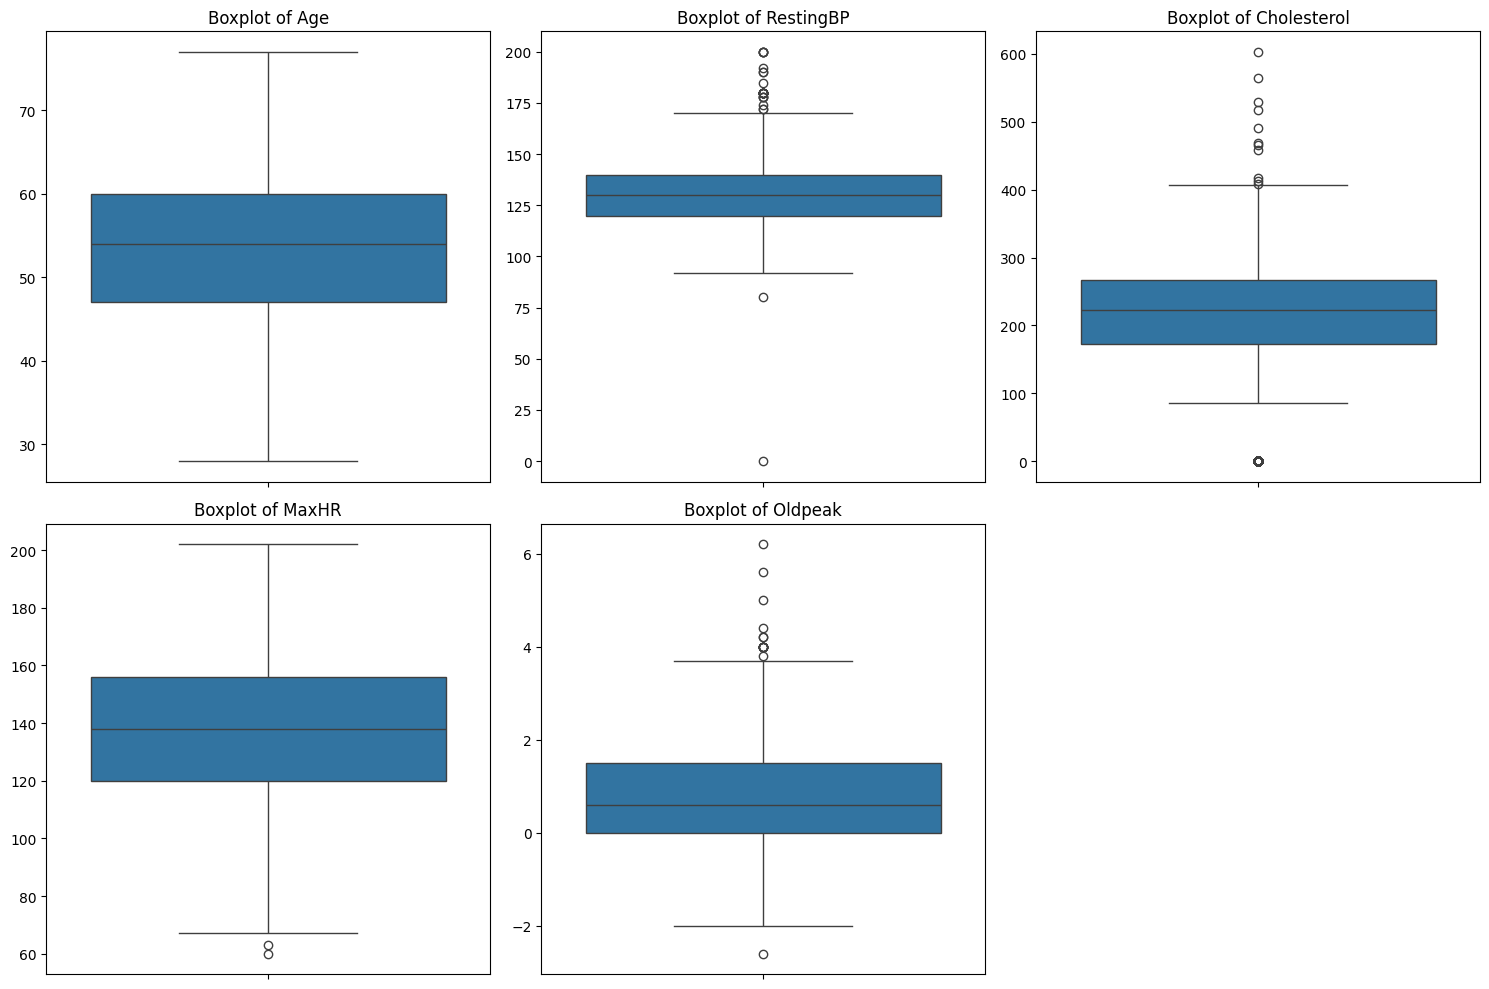

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns for outlier detection
numerical_cols_for_outliers = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Create boxplots to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid if necessary
    sns.boxplot(y=df[col]) # Use the original DataFrame for visualizing unscaled outliers
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [27]:
# Outlier detection using the IQR method

# Create a DataFrame to store detected outliers
outliers_detected = pd.DataFrame(columns=['Feature', 'Lower_Bound', 'Upper_Bound', 'Outlier_Count', 'Outlier_Percentage'])

for col in numerical_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outliers_detected = pd.concat([
        outliers_detected,
        pd.DataFrame([
            {
                'Feature': col,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound,
                'Outlier_Count': outlier_count,
                'Outlier_Percentage': f'{outlier_percentage:.2f}%'
            }
        ])
    ], ignore_index=True)

print("Summary of outlier detection (IQR method):")
display(outliers_detected)


Summary of outlier detection (IQR method):


/tmp/ipykernel_14498/33506943.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  outliers_detected = pd.concat([


,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Age,27.500,79.500,0,0.00%
1,RestingBP,90.000,170.000,28,3.05%
2,Cholesterol,32.625,407.625,183,19.93%
3,MaxHR,66.000,210.000,2,0.22%
4,Oldpeak,-2.250,3.750,16,1.74%


##  4. Feature Selection

Feature selection is a crucial step in preparing our data for machine learning models. It helps in reducing overfitting, improving model accuracy, and decreasing training time. We will identify the most important features, highly correlated variables, and features that should be removed.

### Correlation Heatmap

We will use a correlation heatmap to visualize the pairwise correlation between numerical features. Highly correlated features (either positively or negatively) can sometimes indicate redundancy and potential multicollinearity issues, which might affect certain models.

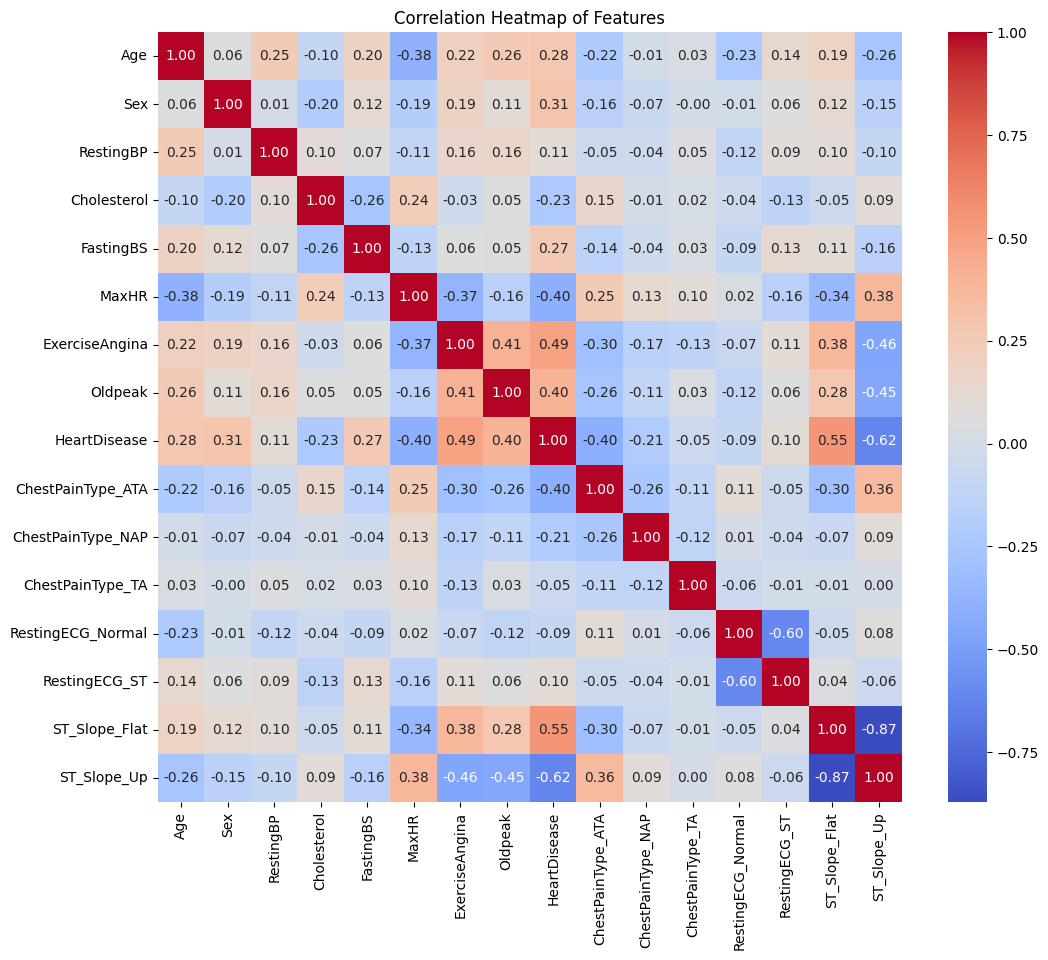

In [ ]:
plt.figure(figsize=(12, 10))
# Select only numerical columns for correlation calculation
numerical_df_encoded = df_encoded.select_dtypes(include=['number', 'bool'])
# Ensure 'HeartDisease' is treated as numerical for correlation
numerical_df_encoded['HeartDisease'] = numerical_df_encoded['HeartDisease'].astype(float)
sns.heatmap(numerical_df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

### 4.2 Feature Importance Analysis

Feature importance refers to techniques that assign a score to input features based on how useful they are at predicting the target variable. For classification tasks, tree-based models like RandomForestClassifier can provide intrinsic feature importances. This will help us understand which features contribute most to predicting heart disease.

Feature Importances:
ST_Slope_Up          0.158299
ST_Slope_Flat        0.110677
Oldpeak              0.109851
Cholesterol          0.104696
MaxHR                0.100584
Age                  0.080612
ExerciseAngina       0.078055
RestingBP            0.077853
ChestPainType_ATA    0.045790
Sex                  0.041192
ChestPainType_NAP    0.027417
FastingBS            0.027175
RestingECG_Normal    0.017474
ChestPainType_TA     0.010501
RestingECG_ST        0.009824
dtype: float64


/tmp/ipykernel_14498/2725713978.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


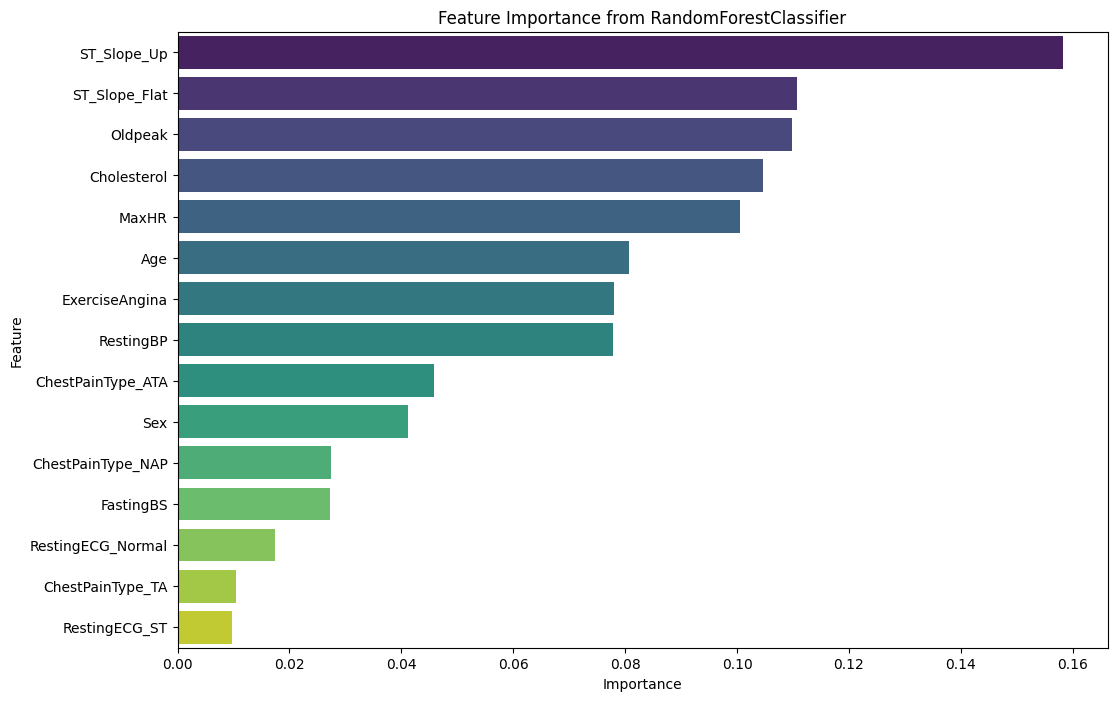

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Separate features (X) and target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Initialize and train a RandomForestClassifier
# Use a fixed random_state for reproducibility
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Feature Importances:")
print(feature_importances)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importance from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 4.3 Features to be Removed

Based on the **Correlation Heatmap** and **Feature Importance Analysis**, we can make informed decisions about which features might be considered for removal.

**Observations from Correlation Heatmap:**
*   We look for pairs of features with very high absolute correlation values (e.g., > 0.8 or < -0.8). If two features are highly correlated, one of them might be redundant, and removing it could simplify the model without significant loss of information. For example, `ST_Slope_Flat` and `ST_Slope_Up` are highly negatively correlated, which is expected as they represent opposite categories of the same feature.
*   Pay attention to correlations with the target variable `HeartDisease`. Features with very low correlation to the target might be less useful for prediction.

**Observations from Feature Importance Analysis:**
*   Features with very low importance scores (close to zero) contribute very little to the model's predictive power and can often be safely removed. This helps in dimensionality reduction and potentially speeds up model training.
*   Features with higher importance scores are considered more critical for the model. We generally want to retain these.

**Decision:**
*   **Highly Correlated Variables:** Review the heatmap to identify features that are strongly correlated with each other. For example, if `Feature A` and `Feature B` are highly correlated, and `Feature A` has a higher importance, we might consider keeping `Feature A` and removing `Feature B`.
*   **Low Importance Features:** Identify features from the `feature_importances` list that have significantly lower importance scores compared to others. These are candidates for removal.

For this specific dataset and the results observed:
*   **From Correlation Heatmap:** `ST_Slope_Up` and `ST_Slope_Flat` are strongly negatively correlated, which is expected as they are one-hot encoded categories of the same original feature. This indicates redundancy if both are kept, but they represent distinct states of the `ST_Slope`.
*   **From Feature Importance Analysis:** Features such as `RestingECG_Normal`, `ChestPainType_TA`, and `RestingECG_ST` show significantly lower importance scores compared to others. These could be considered for removal if simplification is a priority.

At this stage, we will *not* remove any features directly. The decision to remove features should be carefully considered, possibly involving domain expertise and further experimentation, as even low-importance features might capture subtle patterns. We have successfully identified potential candidates for removal if simplification becomes necessary later in the modeling process.

## 5. Saving Processed Data

In [ ]:
# Save the original cleaned DataFrame to a CSV file
df.to_csv('/content/drive/MyDrive/ Data Science Intern/week 2/cleaned_heart_dataset.csv', index=False)
print("Cleaned dataset saved to 'cleaned_heart_dataset.csv'")

# Save the machine-learning-ready DataFrame to a CSV file
df_encoded.to_csv('/content/drive/MyDrive/ Data Science Intern/week 2/ml_ready_heart_dataset.csv', index=False)
print("Machine-learning-ready dataset saved to 'ml_ready_heart_dataset.csv'")

Cleaned dataset saved to 'cleaned_heart_dataset.csv'
Machine-learning-ready dataset saved to 'ml_ready_heart_dataset.csv'
